*Import Libraries*

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings

pd.set_option('display.max_columns', None)

# Visualization style

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

*Load Dataset*

In [2]:
# Load dataset

df = pd.read_csv('mobile_sales_data.csv')

*First Look*

In [3]:
# Display first five records

df.head()

,Product,Brand,Product Code,Product Specification,Price,Inward Date,Dispatch Date,Quantity Sold,Customer Name,Customer Location,Region,Core Specification,Processor Specification,RAM,ROM,SSD
0,Mobile Phone,Motorola,88EB4558,Site candidate activity company there bit insi...,78570,2023-08-02,2023-08-03,6.0,William Hess,South Kelsey,Central,NaN,Snapdragon 7 Gen,12GB,128GB,NaN
1,Laptop,Oppo,416DFEEB,Beat put care fight affect address his.,44613,2023-10-03,2023-10-06,1.0,Larry Smith,North Lisa,South,Ryzen 5,Ryzen 5,8GB,512GB,256GB
2,Mobile Phone,Samsung,9F975B08,Energy special low seven place audience.,159826,2025-03-19,2025-03-20,5.0,Leah Copeland,South Todd,Central,NaN,MediaTek Dimensity,8GB,256GB,NaN
3,Laptop,Sony,73D2A7CC,Friend record hard contain minute we role sea ...,20911,2024-02-06,2024-03-27,1.0,Dan Kirby,New Jordanmouth,South,i7,i7,12GB,64GB,2TB
4,Laptop,Microsoft,CCE0B80D,Program recently feeling save tree hotel people.,69832,2023-08-10,2023-09-10,4.0,Dean Martin,Keithton,East,i7,i7,8GB,128GB,2TB


*Dataset Shape*

In [4]:
# Display dataset dimensions

df.shape

(11482, 16)

*Dataset Information*

In [5]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11482 entries, 0 to 11481
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product                  11482 non-null  object 
 1   Brand                    11482 non-null  object 
 2   Product Code             11482 non-null  object 
 3   Product Specification    11482 non-null  object 
 4   Price                    11482 non-null  int64  
 5   Inward Date              11482 non-null  object 
 6   Dispatch Date            11481 non-null  object 
 7   Quantity Sold            11481 non-null  float64
 8   Customer Name            11481 non-null  object 
 9   Customer Location        11481 non-null  object 
 10  Region                   11481 non-null  object 
 11  Core Specification       5687 non-null   object 
 12  Processor Specification  11481 non-null  object 
 13  RAM                      11481 non-null  object 
 14  ROM                   

*Missing Values*

In [6]:
# Check missing values

df.isnull().sum()

,0
Product,0
Brand,0
Product Code,0
Product Specification,0
Price,0
Inward Date,0
Dispatch Date,1
Quantity Sold,1
Customer Name,1
Customer Location,1


In [12]:
# Remove rows with a small number of missing values

df = df.dropna(
    subset=[
        'Dispatch Date',
        'Quantity Sold',
        'Customer Name',
        'Customer Location',
        'Region',
        'Processor Specification',
        'RAM',
        'ROM'
    ]
)

In [13]:
# Fill missing values for specifications that do not apply to all products

df['Core Specification'] = df['Core Specification'].fillna('Not Available')

df['SSD'] = df['SSD'].fillna('Not Available')

In [14]:
df.isnull().sum()

,0
Product,0
Brand,0
Product Code,0
Product Specification,0
Price,0
Inward Date,0
Dispatch Date,0
Quantity Sold,0
Customer Name,0
Customer Location,0


*Duplicate Records*

In [15]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

*Descriptive Statistics*

In [16]:
# Generate descriptive statistics

df.describe()

,Price,Quantity Sold
count,11481.000000,11481.000000
mean,103104.554917,5.519554
std,56556.062963,2.888700
min,5011.000000,1.000000
25%,53708.000000,3.000000
50%,104048.000000,6.000000
75%,151723.000000,8.000000
max,199999.000000,10.000000


*Column Names*

In [17]:
# Display all column names

df.columns

Index(['Product', 'Brand', 'Product Code', 'Product Specification', 'Price',
       'Inward Date', 'Dispatch Date', 'Quantity Sold', 'Customer Name',
       'Customer Location', 'Region', 'Core Specification',
       'Processor Specification', 'RAM', 'ROM', 'SSD'],
      dtype='object')

*Revenue Column*

In [18]:
# Create Revenue column

df['Revenue'] = df['Price'] * df['Quantity Sold']

df[['Price', 'Quantity Sold', 'Revenue']].head()

,Price,Quantity Sold,Revenue
0,78570,6.0,471420.0
1,44613,1.0,44613.0
2,159826,5.0,799130.0
3,20911,1.0,20911.0
4,69832,4.0,279328.0


*KPI 1*

In [19]:
# Total Revenue

total_revenue = df['Revenue'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $6,518,889,633.00


*KPI 2*

In [20]:
# Total Units Sold

total_units = df['Quantity Sold'].sum()

print(f"Total Units Sold: {total_units:,.0f}")

Total Units Sold: 63,370


*KPI 3*

In [21]:
# Average Product Price

avg_price = df['Price'].mean()

print(f"Average Product Price: ${avg_price:.2f}")

Average Product Price: $103104.55


*KPI 4*

In [22]:
# Top Selling Brand

top_brand = (
    df.groupby('Brand')['Quantity Sold']
    .sum()
    .idxmax()
)

print("Top Selling Brand:", top_brand)

Top Selling Brand: Apple


*KPI Summary*

In [23]:
# KPI Dashboard Summary

print("=" * 50)
print("SALES DASHBOARD KPI SUMMARY")
print("=" * 50)

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Units Sold: {total_units:,.0f}")
print(f"Average Product Price: ${avg_price:.2f}")
print(f"Top Selling Brand: {top_brand}")

SALES DASHBOARD KPI SUMMARY
Total Revenue: $6,518,889,633.00
Total Units Sold: 63,370
Average Product Price: $103104.55
Top Selling Brand: Apple


*Top 10 Brands by Revenue*

In [24]:
# Calculate revenue by brand

brand_revenue = (
    df.groupby('Brand')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

brand_revenue

,Revenue
Brand,
Samsung,348881785.0
Nokia,347750585.0
Apple,345161386.0
Sony,335913094.0
Vivo,333521283.0
Huawei,333189266.0
Lenovo,328998690.0
Toshiba,328993546.0
Motorola,327571547.0


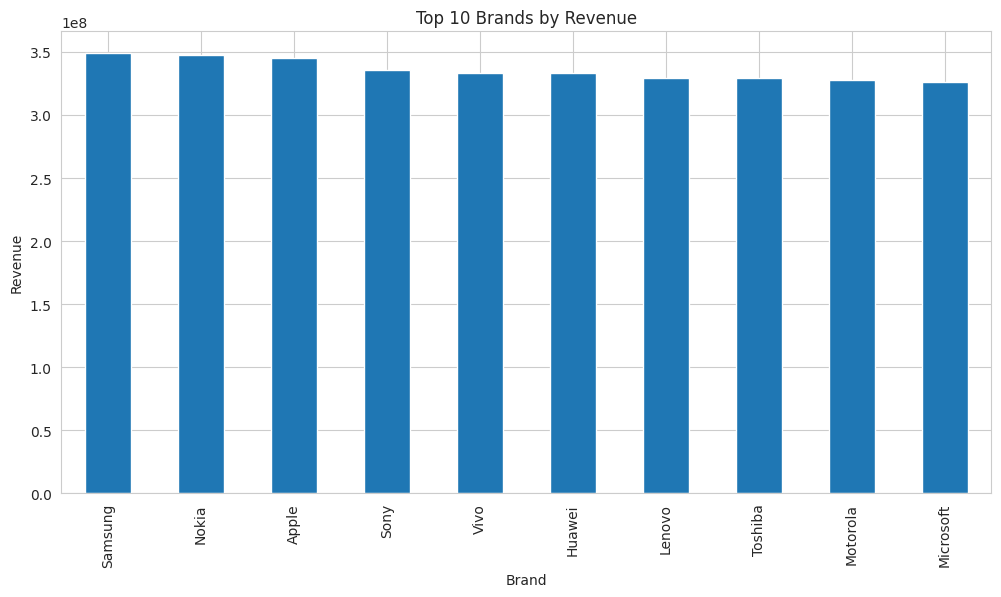

In [25]:
# Top 10 brands by revenue

plt.figure(figsize=(12,6))

brand_revenue.plot(
    kind='bar'
)

plt.title('Top 10 Brands by Revenue')
plt.xlabel('Brand')
plt.ylabel('Revenue')

plt.show()

*Pie Chart — Product Distribution*

In [26]:
# Product distribution

product_counts = df['Product'].value_counts()

product_counts

,count
Product,
Mobile Phone,5794
Laptop,5687


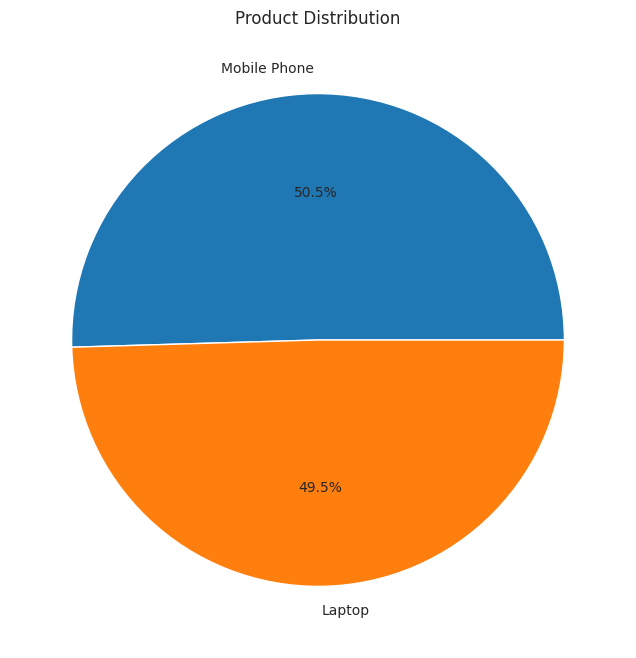

In [27]:
# Product distribution pie chart

plt.figure(figsize=(8,8))

plt.pie(
    product_counts,
    labels=product_counts.index,
    autopct='%1.1f%%'
)

plt.title('Product Distribution')

plt.show()

*Histogram — Price Distribution*

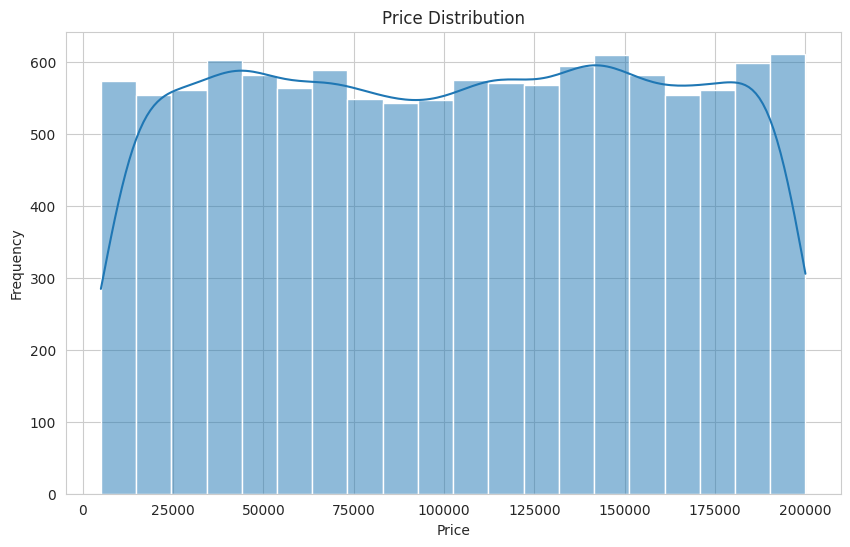

In [28]:
# Product price distribution

plt.figure(figsize=(10,6))

sns.histplot(
    df['Price'],
    bins=20,
    kde=True
)

plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

*Line Chart — Monthly Revenue Trend*

In [29]:
# Convert Dispatch Date to datetime

df['Dispatch Date'] = pd.to_datetime(df['Dispatch Date'])

In [30]:
# Extract month

df['Month'] = df['Dispatch Date'].dt.to_period('M')

In [31]:
# Monthly revenue

monthly_revenue = (
    df.groupby('Month')['Revenue']
    .sum()
)

monthly_revenue

,Revenue
Month,
2023-03,9163913.0
2023-04,123710194.0
2023-05,247593721.0
2023-06,277555823.0
2023-07,264692950.0
2023-08,308164653.0
2023-09,245392144.0
2023-10,280181525.0
2023-11,283525797.0


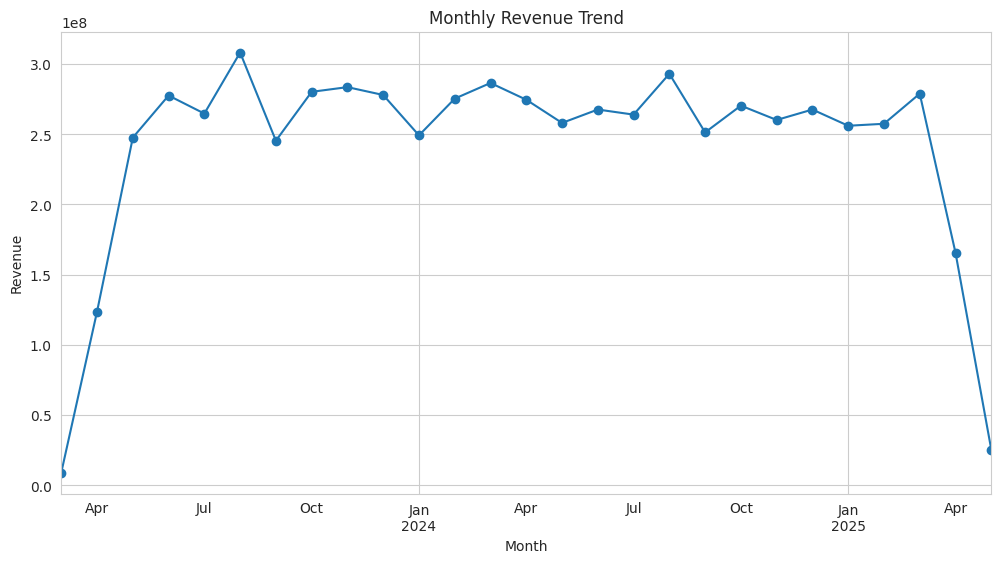

In [32]:
# Monthly revenue trend

plt.figure(figsize=(12,6))

monthly_revenue.plot(
    kind='line',
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

*Correlation Heatmap*

In [33]:
# Correlation matrix

corr = df[['Price','Quantity Sold','Revenue']].corr()

corr

,Price,Quantity Sold,Revenue
Price,1.000000,-0.007916,0.67330
Quantity Sold,-0.007916,1.000000,0.64369
Revenue,0.673300,0.643690,1.00000


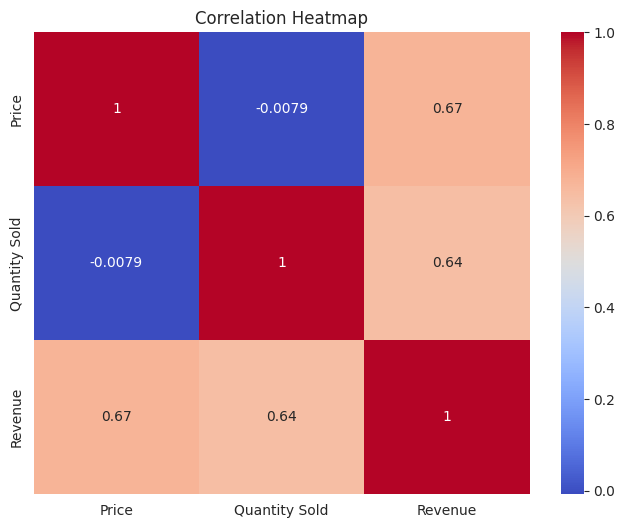

In [34]:
# Correlation heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

*Bonus Graph — Revenue by Region*

In [35]:
# Revenue by region

region_revenue = (
    df.groupby('Region')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

region_revenue

,Revenue
Region,
West,1.375132e+09
Central,1.329931e+09
South,1.309047e+09
East,1.253989e+09
North,1.250791e+09


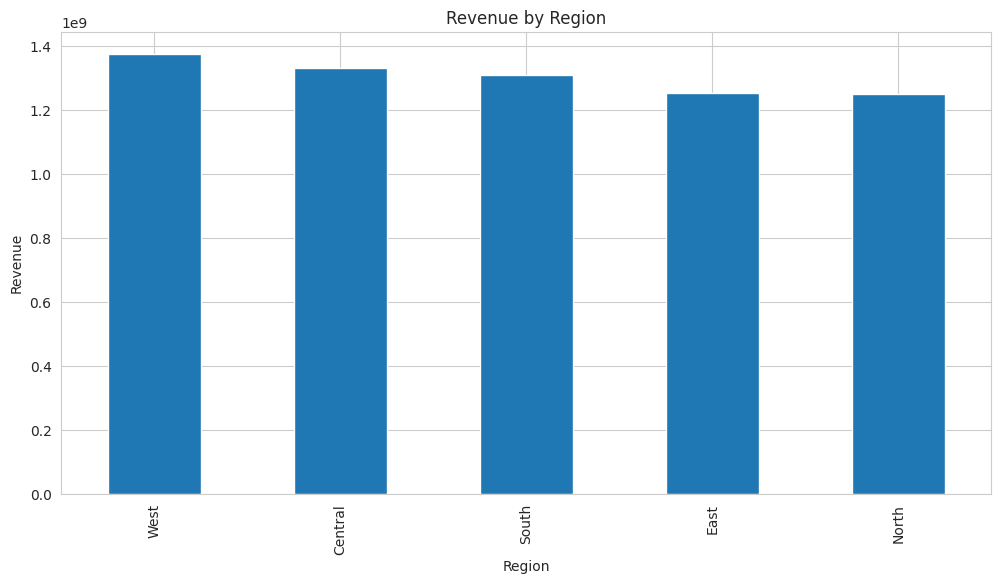

In [36]:
# Revenue by region

plt.figure(figsize=(12,6))

region_revenue.plot(
    kind='bar'
)

plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue')

plt.show()

***KPI Cards Dashboard***

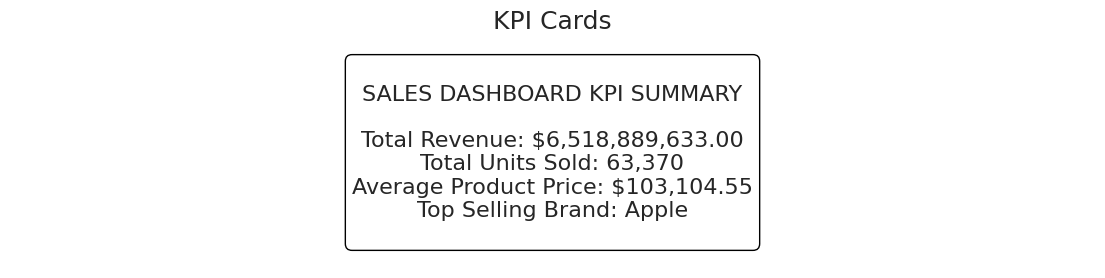

In [40]:
# KPI Cards Visualization

fig, ax = plt.subplots(figsize=(14, 3))

ax.axis('off')

kpi_text = f"""
SALES DASHBOARD KPI SUMMARY

Total Revenue: ${total_revenue:,.2f}
Total Units Sold: {total_units:,.0f}
Average Product Price: ${avg_price:,.2f}
Top Selling Brand: {top_brand}
"""

ax.text(
    0.5,
    0.5,
    kpi_text,
    ha='center',
    va='center',
    fontsize=16,
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='black')
)

plt.title('KPI Cards', fontsize=18)
plt.show()

In [41]:
# Save KPI cards as an image

fig.savefig(
    'kpi_cards.png',
    dpi=300,
    bbox_inches='tight'
)

***Final Dashboard***

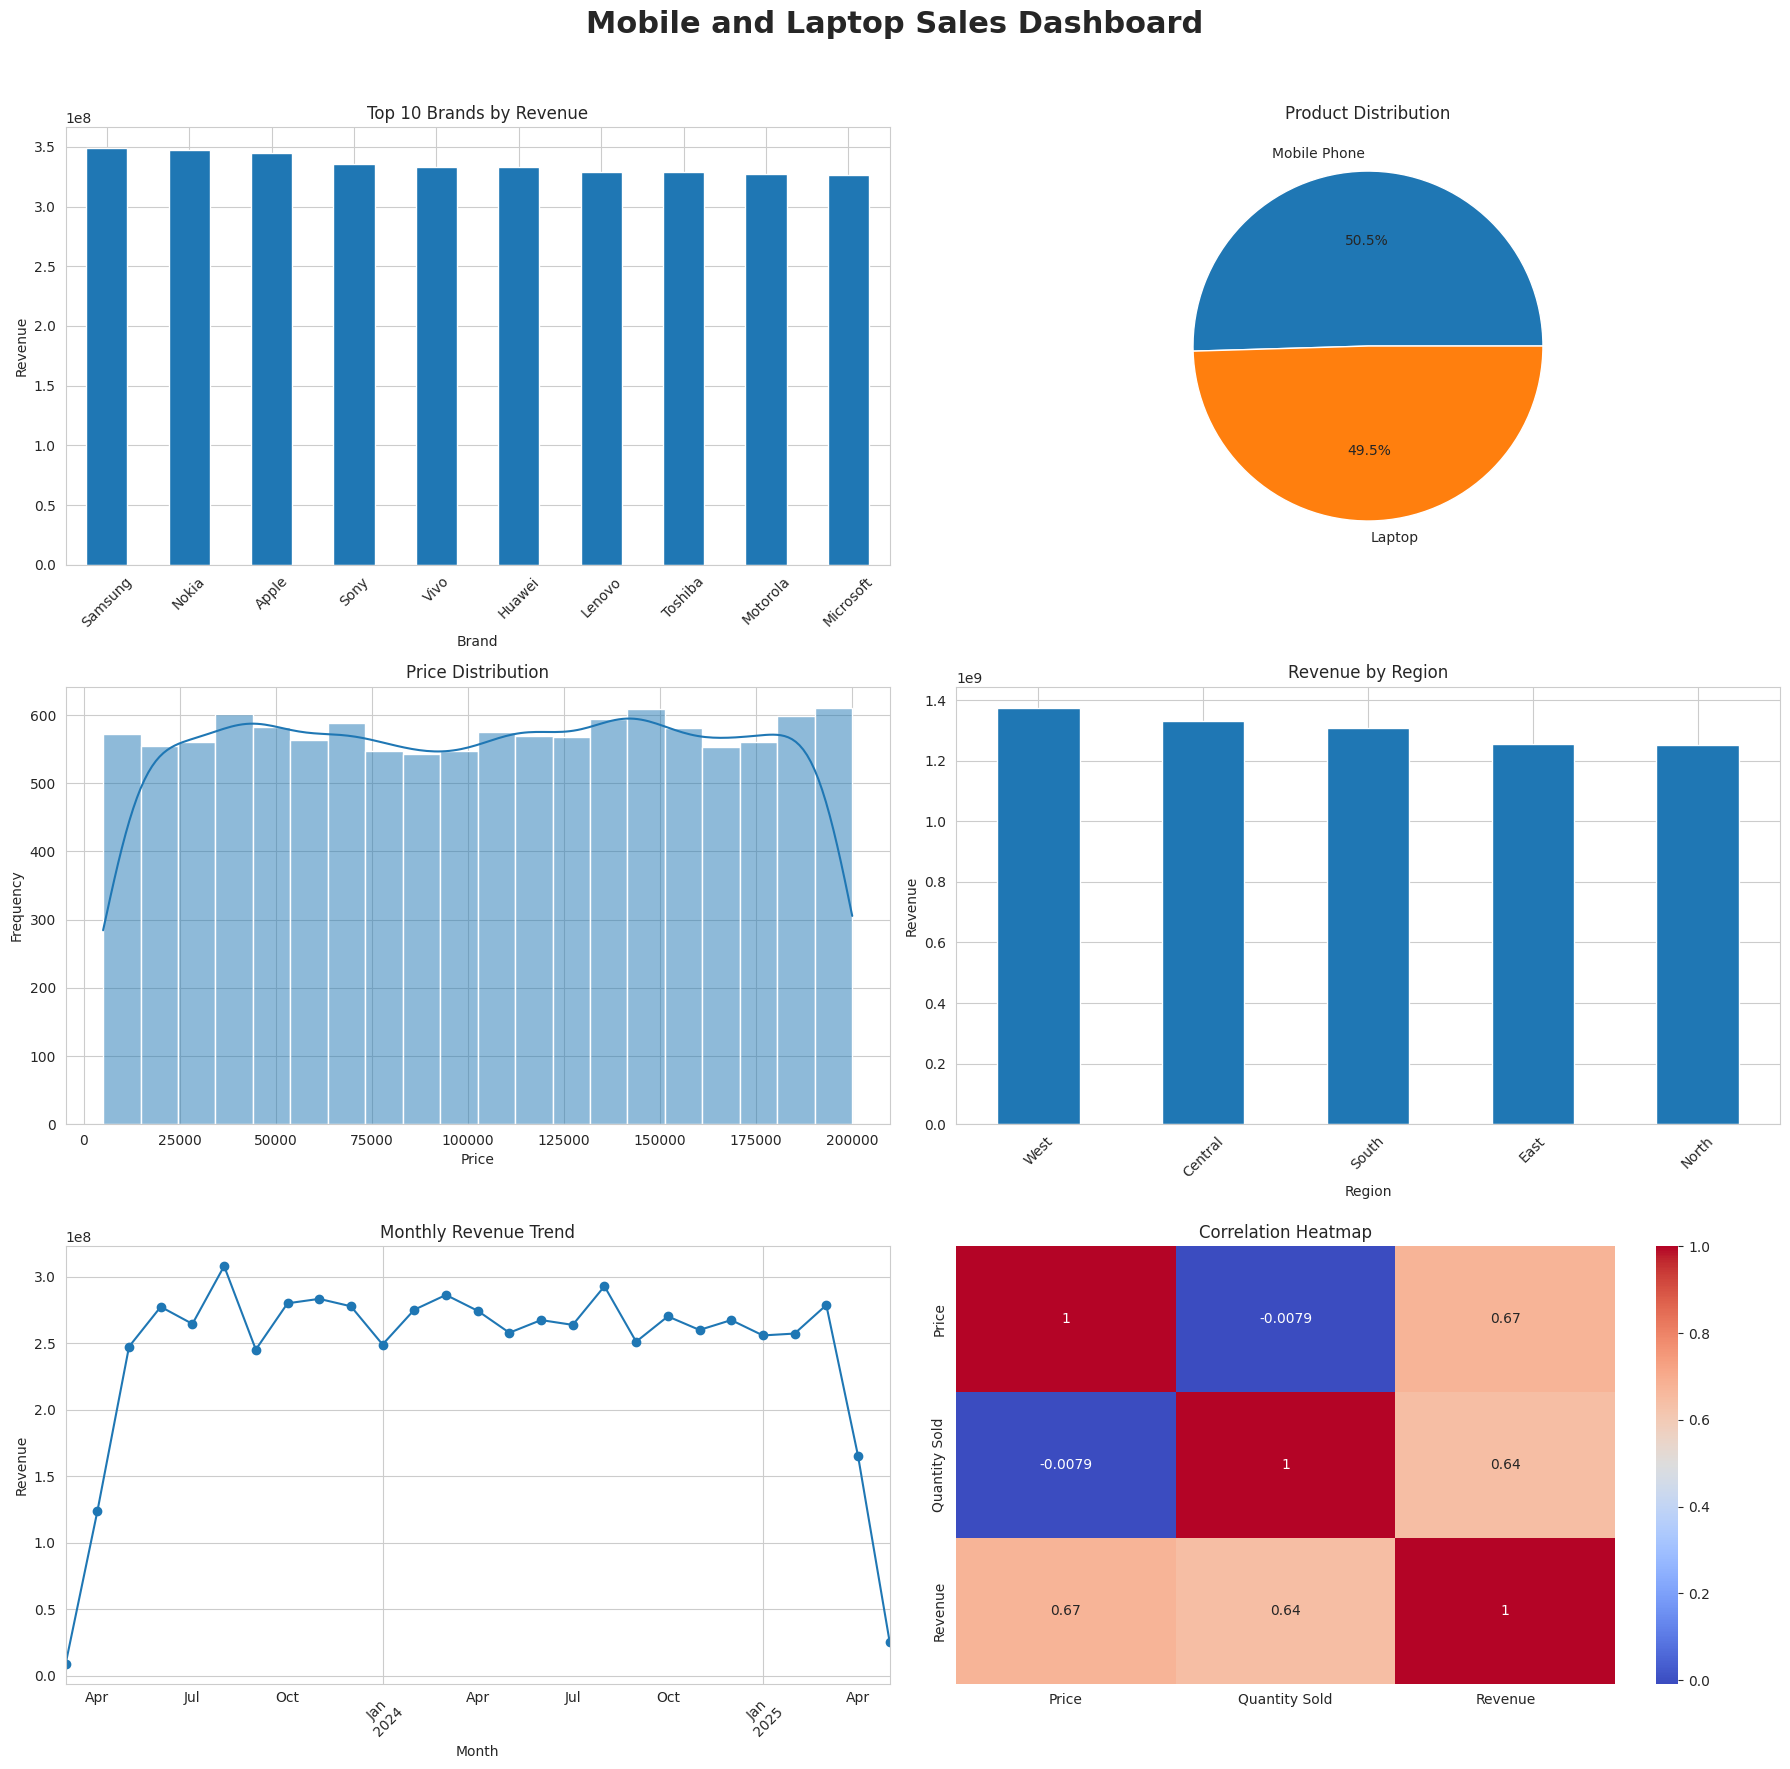

In [38]:
# Final Sales Visualization Dashboard

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

fig.suptitle(
    'Mobile and Laptop Sales Dashboard',
    fontsize=22,
    fontweight='bold'
)

# 1. Top 10 Brands by Revenue
brand_revenue.plot(
    kind='bar',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Top 10 Brands by Revenue')
axes[0, 0].set_xlabel('Brand')
axes[0, 0].set_ylabel('Revenue')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Product Distribution
axes[0, 1].pie(
    product_counts,
    labels=product_counts.index,
    autopct='%1.1f%%'
)
axes[0, 1].set_title('Product Distribution')

# 3. Price Distribution
sns.histplot(
    df['Price'],
    bins=20,
    kde=True,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Price Distribution')
axes[1, 0].set_xlabel('Price')
axes[1, 0].set_ylabel('Frequency')

# 4. Revenue by Region
region_revenue.plot(
    kind='bar',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Revenue by Region')
axes[1, 1].set_xlabel('Region')
axes[1, 1].set_ylabel('Revenue')
axes[1, 1].tick_params(axis='x', rotation=45)

# 5. Monthly Revenue Trend
monthly_revenue.plot(
    kind='line',
    marker='o',
    ax=axes[2, 0]
)
axes[2, 0].set_title('Monthly Revenue Trend')
axes[2, 0].set_xlabel('Month')
axes[2, 0].set_ylabel('Revenue')
axes[2, 0].tick_params(axis='x', rotation=45)

# 6. Correlation Heatmap
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    ax=axes[2, 1]
)
axes[2, 1].set_title('Correlation Heatmap')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [39]:
# Save final dashboard as an image

fig.savefig(
    'sales_dashboard.png',
    dpi=300,
    bbox_inches='tight'
)

***Final Business Insights***

In [42]:
# Final business insights

print("""
Business Insights:

1. The dashboard shows the overall sales performance of mobile phones and laptops.

2. Total revenue and total units sold provide a quick overview of business performance.

3. Top brand analysis helps identify which brands generate the highest revenue.

4. Product distribution shows the share of different product types in the dataset.

5. Regional revenue analysis helps identify high-performing sales regions.

6. Monthly revenue trend shows how sales performance changes over time.

7. Price distribution helps understand the pricing structure of products.

8. Correlation heatmap shows relationships between numerical variables such as price,
   quantity sold, and revenue.

Conclusion:
This dashboard helps transform raw sales data into clear business insights.
It can support better decision-making in sales strategy, product planning,
and regional performance analysis.
""")


Business Insights:

1. The dashboard shows the overall sales performance of mobile phones and laptops.

2. Total revenue and total units sold provide a quick overview of business performance.

3. Top brand analysis helps identify which brands generate the highest revenue.

4. Product distribution shows the share of different product types in the dataset.

5. Regional revenue analysis helps identify high-performing sales regions.

6. Monthly revenue trend shows how sales performance changes over time.

7. Price distribution helps understand the pricing structure of products.

8. Correlation heatmap shows relationships between numerical variables such as price,
   quantity sold, and revenue.

Conclusion:
This dashboard helps transform raw sales data into clear business insights.
It can support better decision-making in sales strategy, product planning,
and regional performance analysis.

